In [1]:
# install dependencies
!pip install -q --disable-pip-version-check awswrangler pyathena
!pip install -q --upgrade boto3 botocore awscli
!pip install -q librosa soundfile audioread

In [2]:
import boto3
import sagemaker
import pandas as pd
import awswrangler as wr
from pyathena import connect
import math
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from datasets import load_dataset

In [ ]:
# Folder initialization

# store zip file and extract data
ZIP_LOCAL = Path().resolve() / "datasets" / "zips" / "CREMAD.zip"
DATA_ROOT = Path().resolve() / "datasets" / "CREMAD"
AUDIO_DIR = DATA_ROOT / "AudioWAV"

# confirm folders exist
ZIP_LOCAL.parent.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

### S3 download dataset file

In [26]:
# define dataset in s3 (not accessible publicly)
S3_ZIP = "s3://ser-multilingual-spr2026msaai540-group2/CREMAD.zip"

# download zip if needed
print("Checking for files at :", str(ZIP_LOCAL) )

if not ZIP_LOCAL.exists():
    !aws s3 cp {S3_ZIP} {str(ZIP_LOCAL)}
else:
    print(f"Zip already exists: {ZIP_LOCAL}")


# unzip if AudioWav doesn't exist
if not AUDIO_DIR.exists() or len(list(AUDIO_DIR.glob("*.wav"))) == 0:
    !unzip -q {str(ZIP_LOCAL)} -d {str(DATA_ROOT)}
else:
    print(f"Audio already extracted: {AUDIO_DIR} (wav files found)")

print("AUDIO_DIR =", str(AUDIO_DIR))

Checking for files at : /Users/victorhugogermano/Development/aai-540-final-project-g2/datasets/zips/CREMAD.zip
fatal error: An error occurred (403) when calling the HeadObject operation: Forbidden
Audio already extracted: /Users/victorhugogermano/Development/aai-540-final-project-g2/datasets/CREMAD/AudioWAV (wav files found)
AUDIO_DIR = /Users/victorhugogermano/Development/aai-540-final-project-g2/datasets/CREMAD/AudioWAV


## File Processing

In [5]:
# create metadata from file names
AUDIO_DIR = Path(AUDIO_DIR)

# CREMA-D emotion map
EMOTION_MAP = {
    "ANG": "anger",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad",
}

# file name pattern
pattern = re.compile(
    r"^(?P<speaker_id>\d+)_"
    r"(?P<utterance>[A-Z]{2,4})_"
    r"(?P<emotion_code>[A-Z]{3})_"
    r"(?P<intensity>[A-Z]{1,2})"
    r"\.wav$",
    re.IGNORECASE
)

rows = []
bad = []

# extract speaker id, emotion, and utterance from audio filename
for fp in sorted(AUDIO_DIR.glob("*.wav")):
    m = pattern.match(fp.name)
    if not m:
        bad.append(fp.name)
        continue

    d = m.groupdict()
    emotion_code = d["emotion_code"].upper()

    rows.append({
        "filepath": str(fp),
        "filename": fp.name,
        "speaker_id": int(d["speaker_id"]),
        "utterance": d["utterance"].upper(),
        "emotion_code": emotion_code,
        "emotion": EMOTION_MAP.get(emotion_code, "unknown"),
        "intensity": d["intensity"].upper(),
    })

meta = pd.DataFrame(rows)

print("Parsed rows:", len(meta))
print("Unparsed filenames:", len(bad))
if bad:
    print("Examples of unparsed filenames:", bad[:10])

meta.head()

Parsed rows: 7442
Unparsed filenames: 0


,filepath,filename,speaker_id,utterance,emotion_code,emotion,intensity
0,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_ANG_XX.wav,1001,DFA,ANG,anger,XX
1,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_DIS_XX.wav,1001,DFA,DIS,disgust,XX
2,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_FEA_XX.wav,1001,DFA,FEA,fear,XX
3,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_HAP_XX.wav,1001,DFA,HAP,happy,XX
4,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_NEU_XX.wav,1001,DFA,NEU,neutral,XX


# Exploratory Data Analysis (EDA)

Here we analyze the distribution of data in our dataset (Emotions, Intensities, Speakers) and visualize the audio features (Waveforms, Spectrograms, MFCCs).

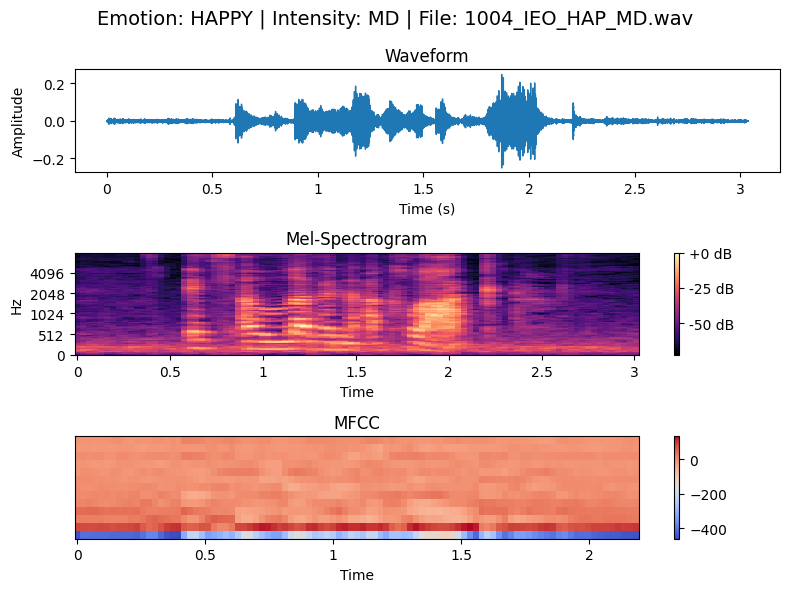

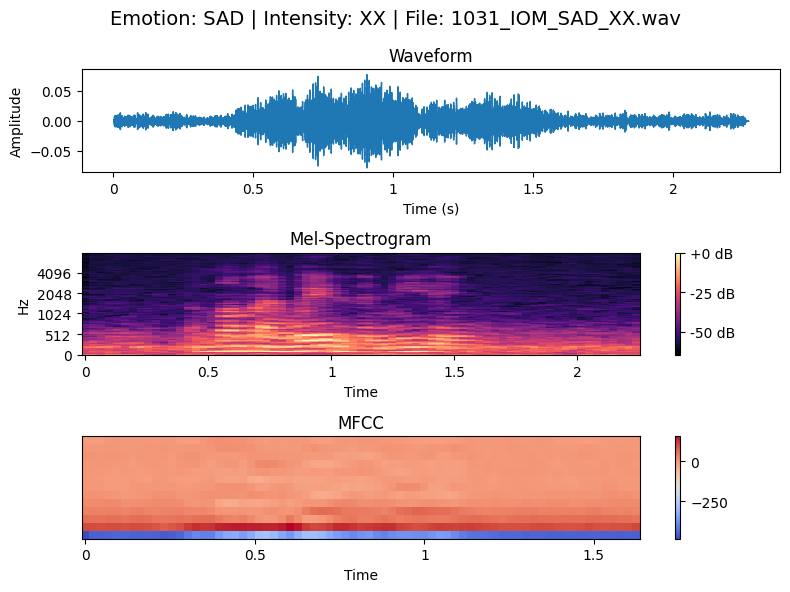

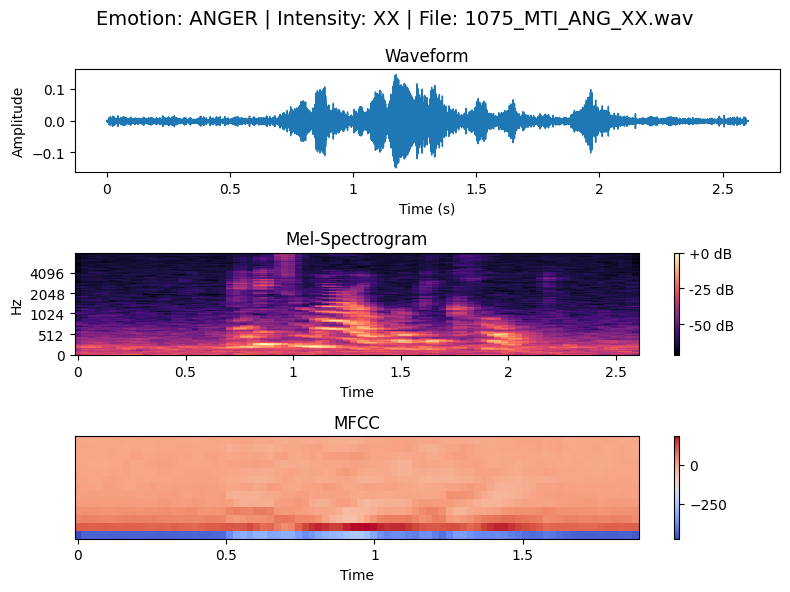

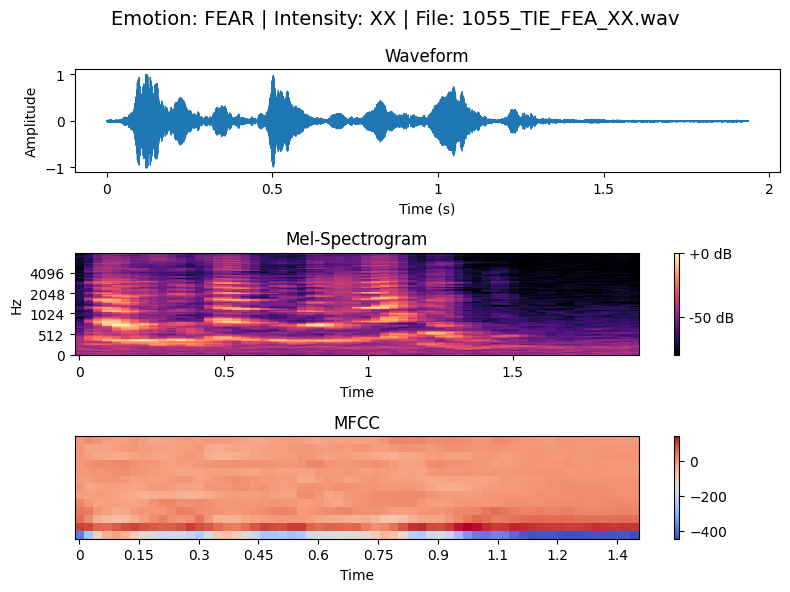

In [25]:
def plot_audio_features(row):
    filepath = row['filepath']
    emotion_label = row['emotion']
    intensity = row['intensity']

    # Load audio
    # Using sr=None to preserve native sampling rate
    y, sr = librosa.load(filepath, sr=None)
    
    # Plot
    fig, ax = plt.subplots(3, 1, figsize=(8, 6))
    fig.suptitle(f"Emotion: {emotion_label.upper()} | Intensity: {intensity} | File: {row['filename']}", fontsize=14)
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title("Waveform")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Amplitude")
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax[1])
    fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
    ax[1].set_title("Mel-Spectrogram")
    
    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img2 = librosa.display.specshow(mfcc, x_axis='time', ax=ax[2])
    fig.colorbar(img2, ax=ax[2])
    ax[2].set_title("MFCC")
    
    plt.tight_layout()
    plt.show()
    
# Visualize a few samples from different emotions
emotions_to_show = ['happy', 'sad', 'anger', 'fear']
# Check if we have these emotions in the dataset to avoid errors
existing_emotions = set(meta['emotion'].unique())
emotions_to_plot = [e for e in emotions_to_show if e in existing_emotions]

for emo in emotions_to_plot:
    # Get a random sample for this emotion
    sample = meta[meta['emotion'] == emo].sample(1).iloc[0]
    plot_audio_features(sample)

### Audio Feature Visualization
Visualizing Waveforms, Mel-Spectrograms, and MFCCs to understand the acoustic features of different emotions.

Total Speakers: 91
Min clips per speaker: 76
Max clips per speaker: 82


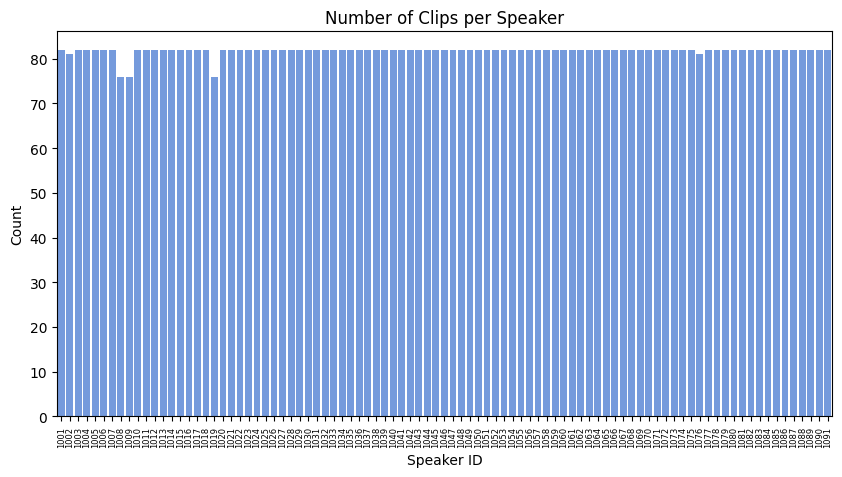

In [23]:
# 3. Speaker Distribution
speaker_counts = meta['speaker_id'].value_counts()
print(f"Total Speakers: {len(speaker_counts)}")
print(f"Min clips per speaker: {speaker_counts.min()}")
print(f"Max clips per speaker: {speaker_counts.max()}")

plt.figure(figsize=(10, 5))
sns.barplot(x=speaker_counts.index, y=speaker_counts.values, color='cornflowerblue')
plt.title("Number of Clips per Speaker")
plt.xlabel("Speaker ID")
plt.ylabel("Count")
plt.xticks(rotation=90, fontsize=6)
plt.show()

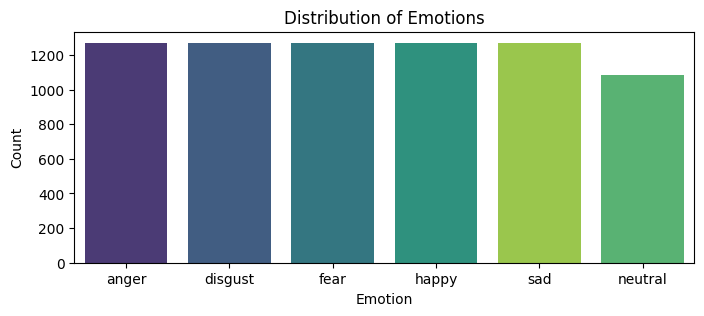

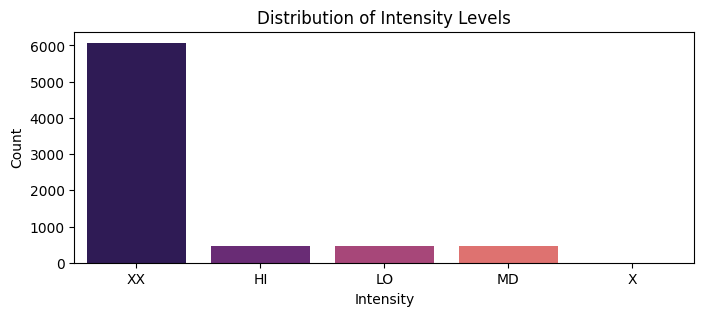

In [24]:
# 1. Emotion Distribution
plt.figure(figsize=(8, 3))
sns.countplot(data=meta, x='emotion', order=meta['emotion'].value_counts().index, palette='viridis', hue='emotion')
plt.title("Distribution of Emotions")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

# 2. Intensity Distribution
plt.figure(figsize=(8, 3))
sns.countplot(data=meta, x='intensity', order=meta['intensity'].value_counts().index, palette='magma', hue='intensity')
plt.title("Distribution of Intensity Levels")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

### Quantitative Analysis of Audio Features

Analyzing specific audio characteristics to see if they differentiate the emotions.

1.  **Duration Analysis**: Checking if the length of the audio clips varies by emotion or speaker. This informs decisions on padding/truncation ensuring model input consistency.
2.  **Energy (RMS)**: Root Mean Square energy is a proxy for loudness. We hypothesize that 'Anger' might have higher energy than 'Sadness'.
3.  **Zero Crossing Rate (ZCR)**: The rate at which the signal changes sign. High ZCR often correlates with noisy or high-frequency signals.



Audio Audio Feature Extraction: Iterating through the dataset and calculate Duration, RMS Energy (loudness), and Zero Crossing Rate (ZCR) (pitch/noise character) for every file.

In [19]:
# Calculate duration, RMS, and ZCR for all files
# (This might take a minute or two for the whole dataset)

durations = []
rms_means = []
zcr_means = []

print(f"Extracting features for {len(meta)} files...")

for i, row in meta.iterrows():
    if (i+1) % 1000 == 0:
        print(f"Processing {i+1}/{len(meta)}")
        
    y, sr = librosa.load(row['filepath'], sr=None)
    
    # Duration
    durations.append(librosa.get_duration(y=y, sr=sr))
    
    # RMS (Energy)
    rms = librosa.feature.rms(y=y)
    rms_means.append(np.mean(rms))
    
    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_means.append(np.mean(zcr))

# Add to dataframe
meta['duration'] = durations
meta['rms_mean'] = rms_means
meta['zcr_mean'] = zcr_means

print("Feature extraction complete.")
meta.head()

Extracting features for 7442 files...
Processing 1000/7442
Processing 2000/7442
Processing 3000/7442
Processing 4000/7442
Processing 5000/7442
Processing 6000/7442
Processing 7000/7442
Feature extraction complete.


,filepath,filename,speaker_id,utterance,emotion_code,emotion,intensity,duration,rms_mean,zcr_mean
0,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_ANG_XX.wav,1001,DFA,ANG,anger,XX,2.275562,0.041986,0.101868
1,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_DIS_XX.wav,1001,DFA,DIS,disgust,XX,2.335688,0.015996,0.093061
2,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_FEA_XX.wav,1001,DFA,FEA,fear,XX,2.168813,0.045776,0.084286
3,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_HAP_XX.wav,1001,DFA,HAP,happy,XX,1.868500,0.042300,0.084878
4,/Users/victorhugogermano/Development/aai-540-f...,1001_DFA_NEU_XX.wav,1001,DFA,NEU,neutral,XX,2.035375,0.020450,0.082031


Duration Visualization: Histograms and boxplots to see if certain emotions are naturally longer or shorter, and to get an idea of the average clip length 

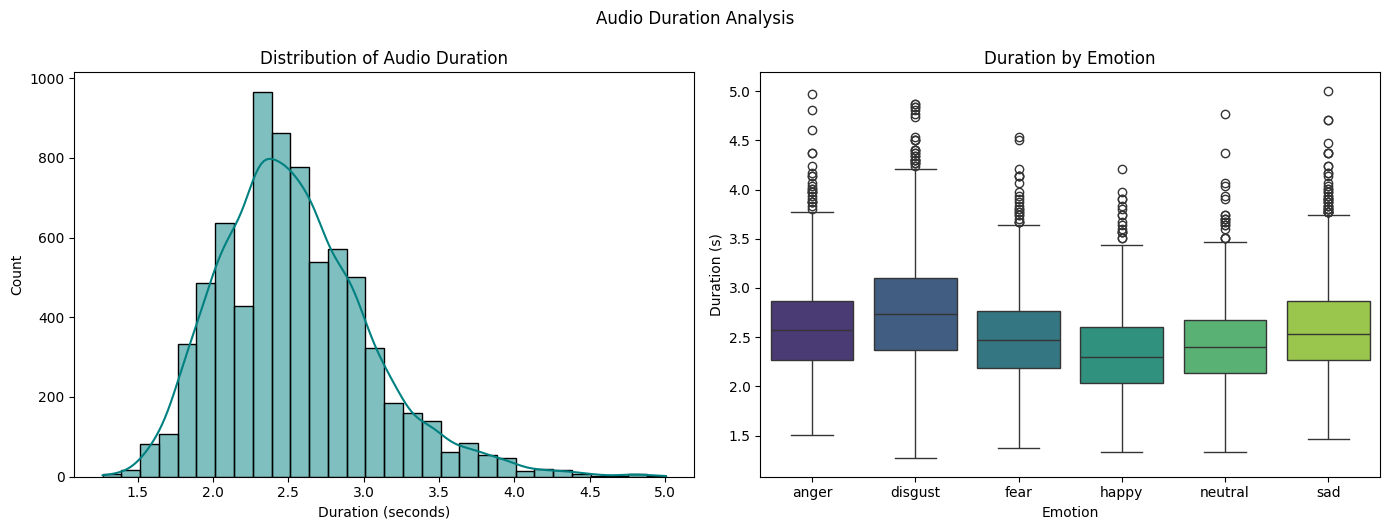

Mean duration: 2.54s
std duration: 0.51s


In [27]:
# Visualizing Duration
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(meta['duration'], bins=30, kde=True, color='teal')
plt.title("Distribution of Audio Duration")
plt.xlabel("Duration (seconds)")

plt.subplot(1, 2, 2)
sns.boxplot(x='emotion', y='duration', data=meta, palette='viridis', hue='emotion')
plt.title("Duration by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Duration (s)")

plt.tight_layout()
plt.suptitle("Audio Duration Analysis", y=1.05)
plt.show()

print(f"Mean duration: {meta['duration'].mean():.2f}s")
print(f"std duration: {meta['duration'].std():.2f}s")

Acoustic Feature Visualization: Boxplots comparing RMS Energy and ZCR across different emotions to see if there are clear statistical distinctions (e.g., is "Anger" consistently louder?).

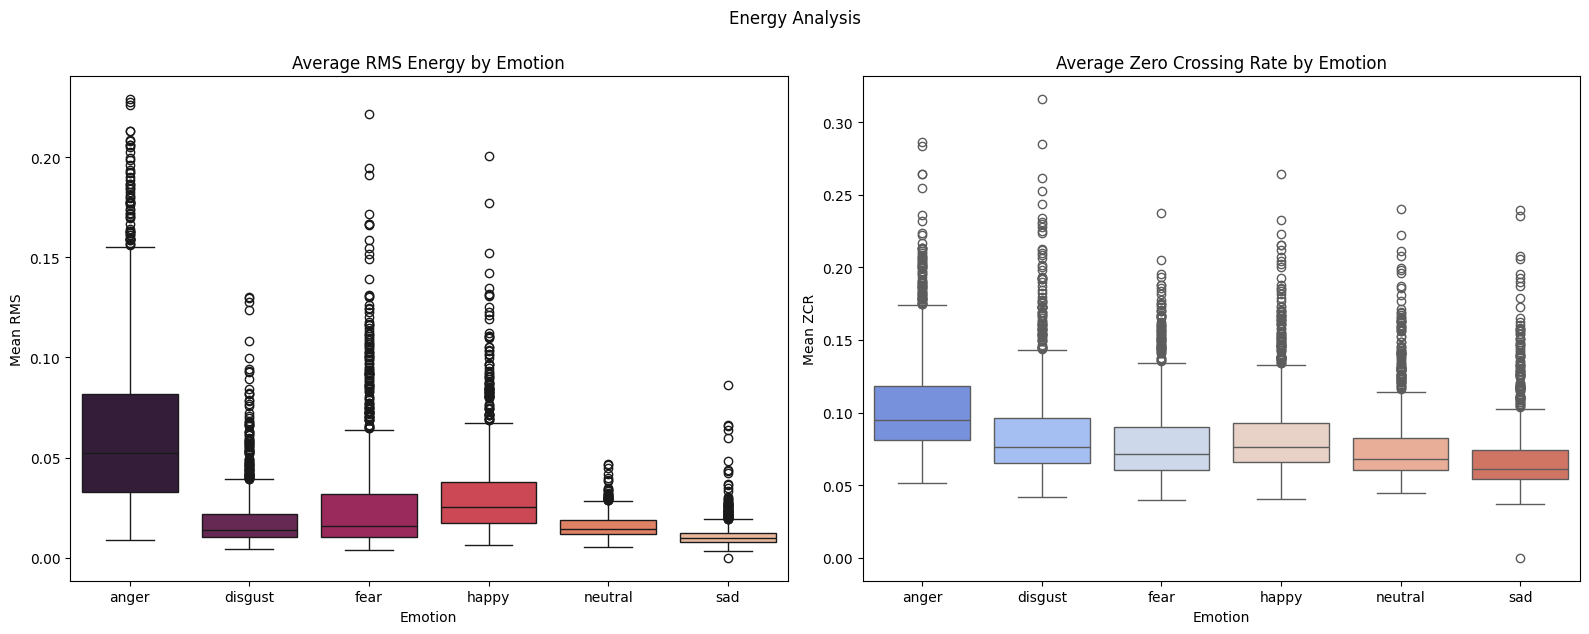

In [28]:
# Visualizing RMS and ZCR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='emotion', y='rms_mean', data=meta, ax=axes[0], palette='rocket', hue='emotion')
axes[0].set_title("Average RMS Energy by Emotion")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Mean RMS")

sns.boxplot(x='emotion', y='zcr_mean', data=meta, ax=axes[1], palette='coolwarm', hue='emotion')
axes[1].set_title("Average Zero Crossing Rate by Emotion")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Mean ZCR")

plt.tight_layout()

plt.suptitle("Energy Analysis", y=1.05)
plt.show()